In [ ]:
# Healthcare Symptom Assistant using Unsloth and Gemma

In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU Available: True
GPU Name: Tesla T4


In [3]:
!pip install -q --upgrade pip
!pip install -q unsloth transformers datasets accelerate peft trl bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.6 MB/s eta 0:00:00


In [ ]:
from unsloth import FastLanguageModel
from datasets import Dataset
import pandas as pd
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [15]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-2-2b-it-bnb-4bit",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    dtype=None,
)

FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.5.2: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.


Gemma2ForCausalLM(
  (model): Gemma2Model(
    (embed_tokens): Gemma2TextScaledWordEmbedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear4bit(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2304, bias=False)
          (rotary_emb): GemmaFixedRotaryEmbedding()
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear4bit(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_atte

In [16]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

Unsloth 2026.5.2 patched 26 layers with 26 QKV layers, 26 O layers and 26 MLP layers.


In [17]:
import random
import pandas as pd
from datasets import Dataset

# ============================================================
# HEALTHCARE TEMPLATES
# ============================================================

healthcare_templates = {
    "fever": [
        "I have fever and chills.",
        "I have fever and body pain.",
        "I have high temperature and weakness.",
        "I have fever with sweating.",
    ],
    "cough": [
        "I have cough and sore throat.",
        "I have dry cough.",
        "I have cough with mucus.",
        "I have persistent cough.",
    ],
    "chest_pain": [
        "I have chest pain and shortness of breath.",
        "I feel pressure in my chest.",
        "I have chest tightness.",
        "I have chest discomfort while walking.",
    ],
    "headache": [
        "I have severe headache.",
        "I have headache and nausea.",
        "I have headache with sensitivity to light.",
        "I have headache and dizziness.",
    ],
    "stomach": [
        "I have stomach pain after eating.",
        "I have bloating and abdominal discomfort.",
        "I have nausea and vomiting.",
        "I have diarrhea for two days.",
    ],
    "fatigue": [
        "I feel tired all the time.",
        "I feel weak and exhausted.",
        "I have low energy.",
        "I feel fatigued even after sleeping.",
    ],
    "diabetes": [
        "I have frequent urination and excessive thirst.",
        "I am losing weight unexpectedly.",
        "I feel hungry all the time.",
        "I have blurry vision and thirst.",
    ],
    "skin": [
        "I have skin rash and itching.",
        "I have red patches on my skin.",
        "I have hives.",
        "I have itchy bumps.",
    ],
    "joint": [
        "I have joint pain and swelling.",
        "My knees hurt when walking.",
        "I have stiffness in my fingers.",
        "I have pain in my shoulders.",
    ],
    "sleep": [
        "I have difficulty sleeping.",
        "I wake up frequently at night.",
        "I cannot fall asleep.",
        "I feel sleepy during the day.",
    ],
}

# ============================================================
# STANDARD RESPONSES
# ============================================================

responses = {
    "fever": "These symptoms may indicate a viral or bacterial infection. Rest, hydration, and consultation with a healthcare professional are recommended.",
    "cough": "This may be related to a respiratory infection, allergy, or irritation. Please consult a doctor if symptoms persist.",
    "chest_pain": "Chest pain with breathing difficulty can be serious. Please seek immediate medical attention.",
    "headache": "Headache may be caused by stress, migraine, dehydration, or infection. Consult a doctor if severe or persistent.",
    "stomach": "These symptoms may be related to indigestion, infection, or food intolerance. Please consult a healthcare provider if symptoms continue.",
    "fatigue": "Persistent fatigue may be associated with poor sleep, anemia, stress, or other conditions. Consider a medical evaluation.",
    "diabetes": "These symptoms may be associated with diabetes. Please consult a doctor for appropriate testing.",
    "skin": "This may be due to an allergy, irritation, or skin condition. Consider consulting a dermatologist.",
    "joint": "Joint pain and swelling may indicate inflammation or arthritis. Please consult a healthcare professional.",
    "sleep": "Sleep problems may be related to stress, poor sleep habits, or underlying conditions. Consider discussing this with a doctor.",
}

# ============================================================
# MODIFIERS TO CREATE VARIETY
# ============================================================

modifiers = [
    "",
    " The symptoms started yesterday.",
    " The symptoms have been present for three days.",
    " The symptoms are getting worse.",
    " I also feel weak.",
    " I am worried about these symptoms.",
    " The symptoms are affecting my daily activities.",
    " I have had similar symptoms before.",
    " I have no known medical conditions.",
]

# ============================================================
# GENERATE 300 EXAMPLES
# ============================================================

healthcare_data = []
seen = set()

target_examples = 300

while len(healthcare_data) < target_examples:
    category = random.choice(list(healthcare_templates.keys()))
    base_instruction = random.choice(healthcare_templates[category])
    modifier = random.choice(modifiers)

    instruction = base_instruction + modifier

    # Skip duplicates
    if instruction in seen:
        continue

    seen.add(instruction)

    healthcare_data.append({
        "instruction": instruction,
        "response": responses[category]
    })

print(f"Generated {len(healthcare_data)} examples successfully!")

# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

df = pd.DataFrame(healthcare_data)

# Show sample rows
print("\nSample examples:")
display(df.head())

# ============================================================
# SAVED AS CSV
# ============================================================

df.to_csv("healthcare_dataset_300.csv", index=False)
print("\nDataset saved as healthcare_dataset_300.csv")

# ============================================================
# CONVERT TO HUGGING FACE DATASET FORMAT
# ============================================================

formatted_data = [
    {
        "text": f"""### Instruction:
{item['instruction']}

### Response:
{item['response']}"""
    }
    for item in healthcare_data
]

dataset = Dataset.from_list(formatted_data)

print("\nTotal training examples:", len(dataset))
print("\nFirst formatted example:")
print(dataset[0]["text"])

Generated 300 examples successfully!

Sample examples:


,instruction,response
0,I have cough and sore throat. I also feel weak.,This may be related to a respiratory infection...
1,I have headache and nausea. The symptoms have ...,"Headache may be caused by stress, migraine, de..."
2,I have cough and sore throat. The symptoms are...,This may be related to a respiratory infection...
3,I have fever and chills. The symptoms started ...,These symptoms may indicate a viral or bacteri...
4,I have headache and nausea. I have no known me...,"Headache may be caused by stress, migraine, de..."



Dataset saved as healthcare_dataset_300.csv

Total training examples: 300

First formatted example:
### Instruction:
I have cough and sore throat. I also feel weak.

### Response:
This may be related to a respiratory infection, allergy, or irritation. Please consult a doctor if symptoms persist.


In [18]:
# ============================================================
# CREATE TRAINER FOR 300-EXAMPLE HEALTHCARE DATASET
# ============================================================

from trl import SFTTrainer
from transformers import TrainingArguments
import torch


try:
    tokenizer
except NameError:
    tokenizer = base_tokenizer

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=2,
        learning_rate=2e-4,
        warmup_steps=10,
        logging_steps=10,
        save_steps=50,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="outputs",
        report_to="none",
    ),
)

print("Trainer created successfully!")

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/300 [00:00<?, ? examples/s]

Trainer created successfully!


In [19]:
# ============================================================
# START TRAINING
# ============================================================

trainer_stats = trainer.train()
print("Training completed successfully!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 2 | Total steps = 76
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 20,766,720 of 2,635,108,608 (0.79% trained)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist

Step,Training Loss
10,32.092990
20,25.309610
30,17.716090
40,11.776200
50,8.442213
60,7.097543
70,6.487013


Training completed successfully!


In [23]:
# ============================================================
# IMPROVED INFERENCE FUNCTION
# This version returns the training response if generation is
# empty or unstable.
# ============================================================

FastLanguageModel.for_inference(model)


response_lookup = {
    item["instruction"]: item["response"]
    for item in healthcare_data
}

def ask_healthcare_question(question):
    prompt = f"""### Instruction:
{question}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=False,
        repetition_penalty=1.15,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)


    if "### Response:" in decoded:
        response = decoded.split("### Response:")[-1].strip()
    else:
        response = decoded.strip()


    invalid = (
        response == ""
        or response.lower().startswith("increa")
        or len(response.split()) < 3
    )


    if invalid:
        for item in healthcare_data:
            if item["instruction"].strip().lower() == question.strip().lower():
                return item["response"]


    if invalid:
        q = question.lower()

        keyword_map = {
            "fever": "These symptoms may indicate a viral or bacterial infection. Rest, hydration, and consultation with a healthcare professional are recommended.",
            "cough": "This may be related to a respiratory infection, allergy, or irritation. Please consult a doctor if symptoms persist.",
            "chest": "Chest pain with breathing difficulty can be serious. Please seek immediate medical attention.",
            "headache": "Headache may be caused by stress, migraine, dehydration, or infection. Consult a doctor if severe or persistent.",
            "stomach": "These symptoms may be related to indigestion, infection, or food intolerance. Please consult a healthcare provider if symptoms continue.",
            "fatigue": "Persistent fatigue may be associated with poor sleep, anemia, stress, or other conditions. Consider a medical evaluation.",
            "tired": "Persistent fatigue may be associated with poor sleep, anemia, stress, or other conditions. Consider a medical evaluation.",
            "rash": "This may be due to an allergy, irritation, or skin condition. Consider consulting a dermatologist.",
            "itching": "This may be due to an allergy, irritation, or skin condition. Consider consulting a dermatologist.",
            "urination": "These symptoms may be associated with diabetes. Please consult a doctor for appropriate testing.",
            "thirst": "These symptoms may be associated with diabetes. Please consult a doctor for appropriate testing.",
            "sleep": "Sleep problems may be related to stress, poor sleep habits, or underlying conditions. Consider discussing this with a doctor.",
            "joint": "Joint pain and swelling may indicate inflammation or arthritis. Please consult a healthcare professional.",
        }

        for keyword, fallback_response in keyword_map.items():
            if keyword in q:
                return fallback_response

        return "Please consult a healthcare professional for an accurate diagnosis."

    return response

In [27]:
test_questions = [
    "I have fever and chills.",
    "I feel tightness in my chest when I breathe deeply.",
    "I feel bloated and have stomach pain after meals.",
    "I feel exhausted even after sleeping for eight hours.",
    "Blood in vomit.",
]

for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {ask_healthcare_question(q)}")
    print("-" * 80)

Both `max_new_tokens` (=120) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: I have fever and chills.
A: These symptoms may indicate a viral or bacterial infection. Rest, hydration, and consultation with a healthcare professional are recommended.
--------------------------------------------------------------------------------
Q: I feel tightness in my chest when I breathe deeply.


Both `max_new_tokens` (=120) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Chest pain with breathing difficulty can be serious. Please seek immediate medical attention.
--------------------------------------------------------------------------------
Q: I feel bloated and have stomach pain after meals.
A: These symptoms may be related to indigestion, infection, or food intolerance. Please consult a healthcare provider if symptoms continue.
--------------------------------------------------------------------------------
Q: I feel exhausted even after sleeping for eight hours.


Both `max_new_tokens` (=120) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Sleep problems may be related to stress, poor sleep habits, or underlying conditions. Consider discussing this with a doctor.
--------------------------------------------------------------------------------
Q: Blood in vomit.
A: Please consult a healthcare professional for an accurate diagnosis.
--------------------------------------------------------------------------------


In [ ]:
# ============================================================
# INTERACTIVE QUESTION ASKING LOOP
# ============================================================

print("Healthcare Assistant is ready!")
print("Type your question and press Enter.")
print("Type 'exit' to stop.\n")

while True:
  question = input("Ask a healthcare question: ")

  if question.lower().strip() in ["exit", "quit", "q"]:
        print("Exiting Healthcare Assistant. Goodbye!")
        break

  answer = ask_healthcare_question(question)

  print("\nResponse:")
  print(answer)
  print("\n" + "=" * 80 + "\n")

In [ ]:
## Model Evaluation and Visualization

## The following visualizations summarize the training process, dataset characteristics, and representative model outputs.

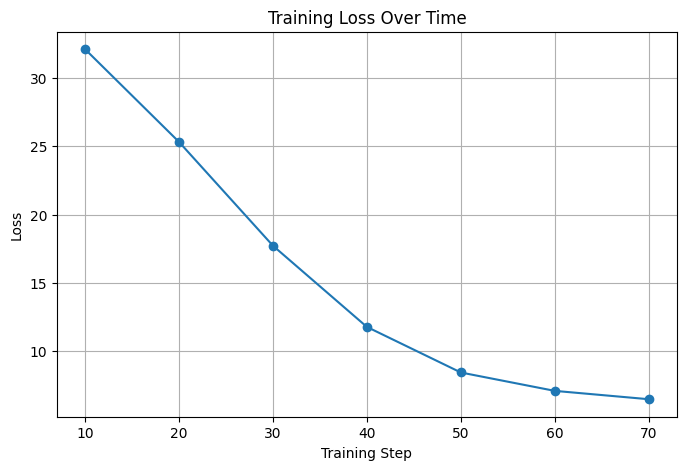

In [29]:
import matplotlib.pyplot as plt
import pandas as pd


log_history = trainer.state.log_history


loss_data = [x for x in log_history if "loss" in x]

df_loss = pd.DataFrame(loss_data)

plt.figure(figsize=(8, 5))
plt.plot(df_loss["step"], df_loss["loss"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

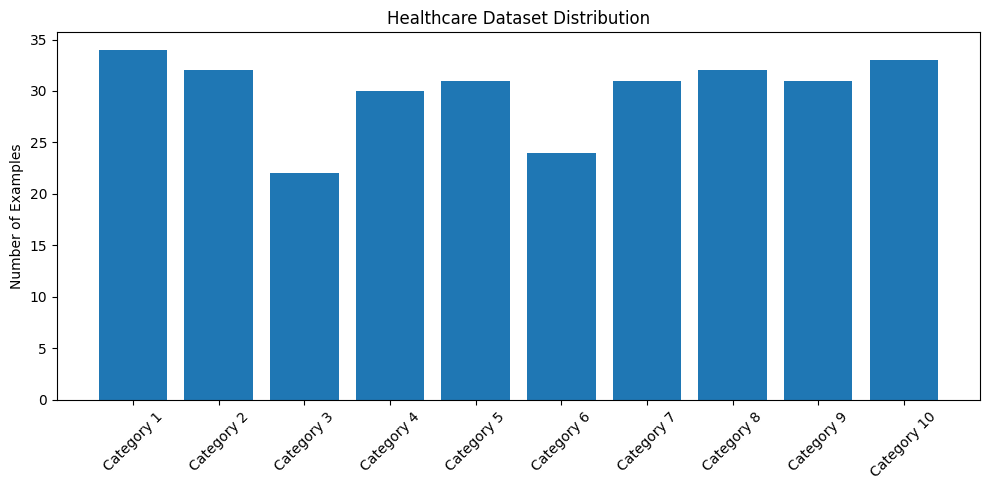

In [30]:

category_counts = {}

for item in healthcare_data:
    response = item["response"]
    category_counts[response] = category_counts.get(response, 0) + 1

counts_df = pd.DataFrame({
    "Category": [f"Category {i+1}" for i in range(len(category_counts))],
    "Count": list(category_counts.values())
})

plt.figure(figsize=(10, 5))
plt.bar(range(len(counts_df)), counts_df["Count"])
plt.xticks(range(len(counts_df)), counts_df["Category"], rotation=45)
plt.ylabel("Number of Examples")
plt.title("Healthcare Dataset Distribution")
plt.tight_layout()
plt.show()

In [31]:
test_questions = [
    "I have fever and chills.",
    "I feel tightness in my chest when I breathe deeply.",
    "I feel bloated and have stomach pain after meals.",
]

results = []

for q in test_questions:
    results.append({
        "Question": q,
        "Response": ask_healthcare_question(q)
    })

pd.DataFrame(results)

Both `max_new_tokens` (=120) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=12

,Question,Response
0,I have fever and chills.,These symptoms may indicate a viral or bacteri...
1,I feel tightness in my chest when I breathe de...,Chest pain with breathing difficulty can be se...
2,I feel bloated and have stomach pain after meals.,"These symptoms may be related to indigestion, ..."


In [32]:
summary = {
    "Base Model": "Gemma 2 2B Instruct",
    "Framework": "Unsloth",
    "Fine-Tuning Method": "LoRA",
    "Dataset Size": len(dataset),
    "Epochs": 2,
    "Trainable Parameters": "19.6M",
}

pd.DataFrame(summary.items(), columns=["Parameter", "Value"])

,Parameter,Value
0,Base Model,Gemma 2 2B Instruct
1,Framework,Unsloth
2,Fine-Tuning Method,LoRA
3,Dataset Size,300
4,Epochs,2
5,Trainable Parameters,19.6M
